In [50]:
from inspect import _void
import numpy as np
import cv2
import time
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
test_dir = 'C:\\Users\\hp\\Desktop\\gj\\circle_light\\3\\'
img = cv2.imread(os.path.join(test_dir, "Camcap_20220117_162708.bmp"), 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [52]:
retval, img_binary = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY) #
img_erod = cv2.erode(img_binary, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)))

In [53]:
mask = np.zeros([img.shape[0]+2, img.shape[1]+2], dtype=np.uint8) #不填充掩膜里面的非零区域

retval, image, mask, rect	 = cv2.floodFill(img, mask, (1000, 1800), 0, loDiff=10, upDiff=50)

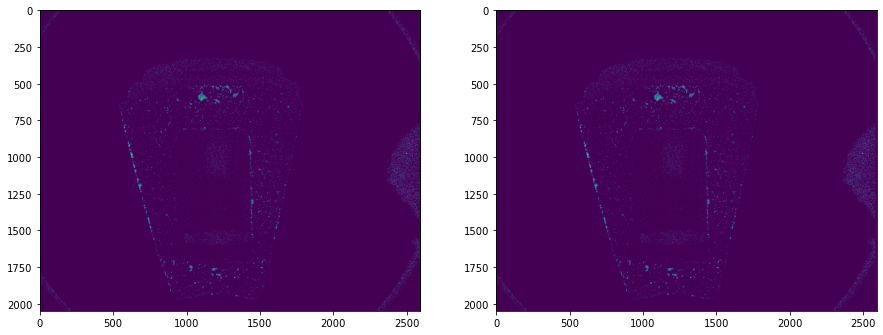

In [54]:
fig = plt.figure(figsize=(15,15))
axs1, axs2 = fig.add_subplot(1,2,1) ,fig.add_subplot(1,2,2) 
axs1.imshow(img)
axs2.imshow(image)

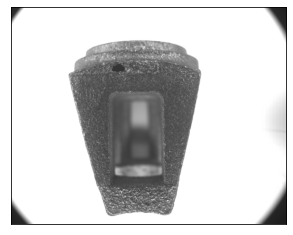

In [55]:
#图像颜色压缩
# Note: this requires the ``pillow`` package to be installed
from sklearn.datasets import load_sample_image
test_dir = 'C:\\Users\\hp\\Desktop\\gj\\circle_light\\3\\'
chi = cv2.imread(os.path.join(test_dir, "Camcap_20220117_162708.bmp"), 1)
chi = cv2.cvtColor(chi, cv2.COLOR_BGR2RGB)
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(chi);

In [56]:
chi.shape

(2048, 2592, 3)

In [57]:
data = chi / 255.0 # use 0...1 scale
data = data.reshape(-1, 3)
data.shape

(5308416, 3)

In [58]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data
    
    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

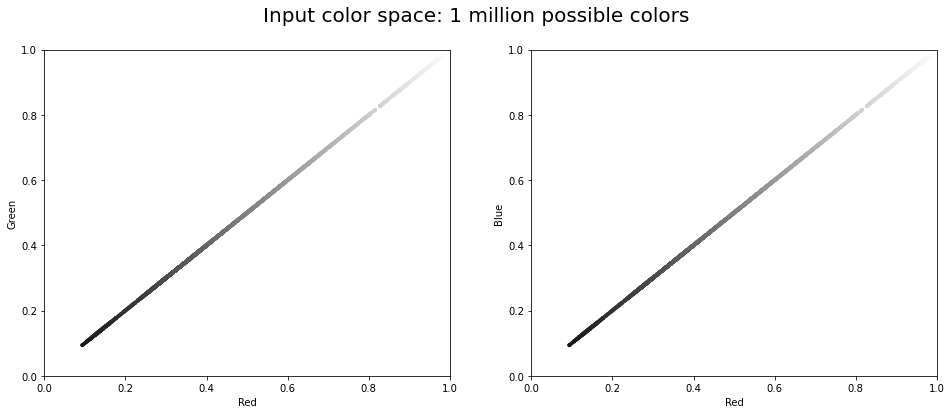

In [59]:
plot_pixels(data, title='Input color space: 1 million possible colors')

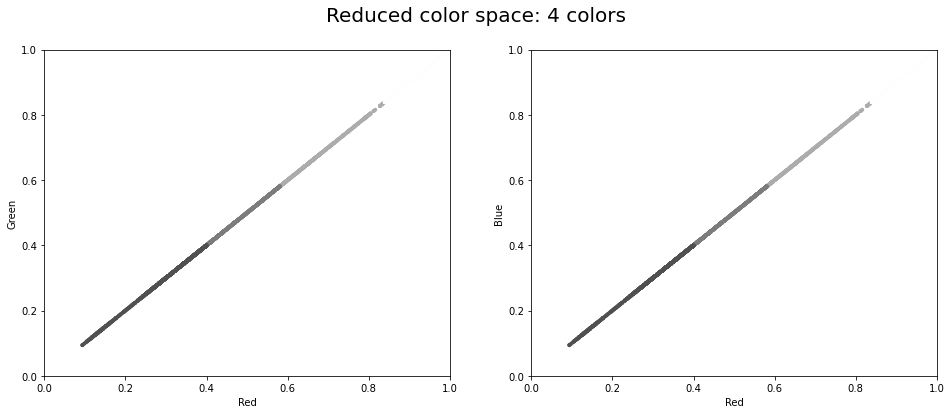

In [60]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(4)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 4 colors")

In [61]:
chi.shape

(2048, 2592, 3)

(2048, 2592, 3)


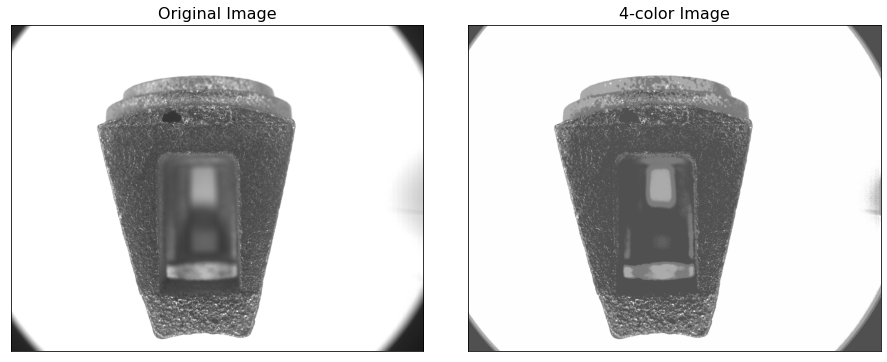

In [62]:
china_recolored = new_colors.reshape(chi.shape)
china_recolored = (china_recolored*255).astype(np.uint8)
print(china_recolored.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(chi)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(china_recolored)
ax[1].set_title('4-color Image', size=16);

In [63]:
china_recolored.shape

(2048, 2592, 3)

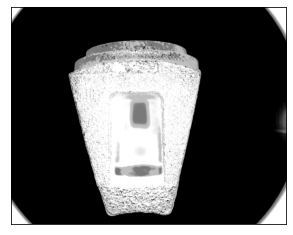

In [64]:
china_recolored = cv2.cvtColor(china_recolored, cv2.COLOR_RGB2GRAY)
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(china_recolored, cmap= plt.cm.binary);

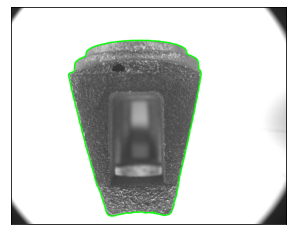

In [65]:

retval, img_binary = cv2.threshold(china_recolored, 220, 255, cv2.THRESH_BINARY) #

img2 = cv2.Laplacian(img_binary, -1)
contours, hierarchy	= cv2.findContours(img2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
contours_size = np.array([len(s) for s in contours ])
sort_index = np.argsort(-contours_size) #返回从大到小的索引,降序排列
idx = sort_index[0] #取一个轮廓，按t增加索引
cv2.drawContours(chi, contours, idx, (0,255,0), thickness=12) #画原轮廓，绿色

ax = plt.axes(xticks=[], yticks=[])
# ax.imshow(img_binary, cmap=plt.cm.binary);
ax.imshow(chi)